In [4]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot
import sys
import seaborn as sns
from tqdm import tqdm
import networkx as nx

import atlasify as atl
from particle import Particle
atl.ATLAS = "ColliderML"

sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/OtherLibraries/pyedm4hep")
from pyedm4hep import EDM4hepEvent, EDM4hepEventBatch

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Roadmap

1. Load an edm4hep file
2. Load the particles and tracker hits
3. Inspect **Hidden Valley** truth particles (focus on `4900*` PDGs and semi-visible jet structure)
4. Sanity-check that only the intended dark hadrons are stable (e.g. stable neutral `4900111`, prompt decays for others)


## Loading

In [5]:
# Load the edm4hep file with uproot
edm_input_file = "/global/cfs/cdirs/m4958/data/ColliderML/simulation/hard_scatter/hidden_valley/v1/runs/0/edm4hep.root"
# Hidden-valley run currently produces 8 events in run 0
event = EDM4hepEventBatch(edm_input_file, events=(0, 9), condense_calo=False, full_load=True)


In [6]:
tracker_hits = event.get_tracker_hits_df()
calo_hits = event.get_calo_hits_df()
particles = event.get_particles_df()
daughters = event.get_daughters_df()
parents = event.get_parents_df()

In [7]:
particles

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,daughters_begin,daughters_end,vr,endpoint_r,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits
0,0,0,2212,0,1.000000,-0.127579,0.938270,-0.012725,-0.000778,16.398314,...,0,2,0.012749,0.012749,7000.000000,6999.061730,0,False,0,0
1,0,1,1,0,-0.333333,-0.127579,0.000000,-0.012725,-0.000778,16.398314,...,2,3,0.012749,0.012749,1517.636261,1517.636261,1,False,0,0
2,0,2,2203,0,1.333333,-0.127579,0.771330,-0.012725,-0.000778,16.398314,...,3,4,0.012749,0.012749,5482.354130,5481.582800,2,False,0,0
3,0,3,2212,0,1.000000,-0.127579,0.938270,-0.012725,-0.000778,16.398314,...,4,7,0.012749,0.012749,7000.000000,6999.061730,3,False,0,0
4,0,4,21,0,0.000000,-0.127579,0.000000,-0.012725,-0.000778,16.398314,...,7,8,0.012749,0.012749,1166.758090,1166.758090,4,False,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85328,7,17824,-11,1426063360,1.000000,5.244915,0.000511,1295.637198,391.656991,-760.703470,...,21136,21136,1353.540153,1367.521698,0.133336,0.132825,17824,True,0,0
85329,7,17825,11,1426063360,-1.000000,5.033818,0.000511,1242.976246,374.052783,-730.104959,...,21136,21136,1298.039072,1317.871195,0.110241,0.109730,17825,True,0,0
85330,7,17826,11,1426063360,-1.000000,4.978039,0.000511,1228.143886,370.231879,-723.485402,...,21136,21136,1282.734987,1292.609445,0.138342,0.137831,17826,True,0,0
85331,7,17827,11,1426063360,-1.000000,4.922745,0.000511,1214.200555,366.013448,-715.574895,...,21136,21136,1268.167509,1288.368417,0.177136,0.176625,17827,True,0,0


In [8]:
particles.PDG.unique()

array([      2212,          1,       2203,         21,        111,
             -211,        331,        323,       -311,       -213,
              223,        221,        211,        113,        213,
          4900001,   -4900001,    4900101,         -2,          2,
              321,        311,       2112,      -2114,       2114,
            -2214,      -2212,       1114,      -1114,       3224,
               22,        310,    4900021,        130,      -2112,
             3122,         -5,          5,       -321,         -1,
         -4900101,   -4900213,    4900213,   -4900211,    4900113,
          4900211,        513,       -323,        511,         11,
              -11,      -4324,      -4232,      -3222,          4,
               -4,        411,       2224,        -13,         14,
             -313,       -513,       -413,       -511,       -421,
       1000010020, 1000140280,         13, 1000010030, 1000020030,
       1000130270, 1000140290, 1000140300, 1000020040,       2

In [9]:
particles.columns

Index(['event_id', 'subentry', 'PDG', 'simulatorStatus', 'charge', 'time',
       'mass', 'vx', 'vy', 'vz', 'px', 'py', 'pz', 'parents_begin',
       'parents_end', 'generatorStatus', 'endpoint_x', 'endpoint_y',
       'endpoint_z', 'daughters_begin', 'daughters_end', 'vr', 'endpoint_r',
       'energy', 'kinetic_energy', 'particle_id', 'created_in_simulation',
       'num_tracker_hits', 'num_calo_hits'],
      dtype='object')

In [17]:
particles[particles.PDG == 36]

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,daughters_begin,daughters_end,vr,endpoint_r,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits
384,0,384,36,0,0.0,0.209118,55.0,-0.020831,-0.030924,-65.98809,...,1315,1317,0.037286,3.059550,84.504500,29.504500,384,False,0,0
385,0,385,36,0,0.0,0.209118,55.0,-0.020831,-0.030924,-65.98809,...,1317,1319,0.037286,103.875347,66.844952,11.844952,385,False,0,0


In [18]:
daughters.iloc[1315:1317]

,event_id,subentry,particle_id,collectionID
1315,0,1315,386,2714477136
1316,0,1316,387,2714477136


In [20]:
daughters.iloc[1317:1319]

,event_id,subentry,particle_id,collectionID
1317,0,1317,388,2714477136
1318,0,1318,389,2714477136


In [19]:
particles.iloc[386:388]

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,daughters_begin,daughters_end,vr,endpoint_r,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits
386,0,386,5,0,-0.333333,0.224956,4.8,-0.349017,-3.039578,-64.029819,...,1319,1320,3.05955,3.05955,51.694807,46.894807,386,False,0,0
387,0,387,-5,0,0.333333,0.224956,4.8,-0.349017,-3.039578,-64.029819,...,1320,1322,3.05955,3.05955,32.809693,28.009693,387,False,0,0


In [21]:
particles.iloc[388:390]

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,daughters_begin,daughters_end,vr,endpoint_r,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits
388,0,388,5,0,-0.333333,0.850758,4.8,97.865932,-34.818774,-31.934521,...,1322,1324,103.875347,103.875347,46.379736,41.579736,388,False,0,0
389,0,389,-5,0,0.333333,0.850758,4.8,97.865932,-34.818774,-31.934521,...,1324,1325,103.875347,103.875347,20.465216,15.665216,389,False,0,0


In [24]:
daughters

,event_id,subentry,particle_id,collectionID
0,0,0,1,2714477136
1,0,1,2,2714477136
2,0,2,3,2714477136
3,0,3,8,2714477136
4,0,4,9,2714477136
...,...,...,...,...
70048,7,13449,8447,2714477136
70049,7,13450,8454,2714477136
70050,7,13451,8458,2714477136
70051,7,13452,8459,2714477136


In [26]:
event_particles = particles[particles.event_id == 2]

In [27]:
event_daughters = daughters[daughters.event_id == 2]

In [28]:
event_particles[event_particles.PDG == 36]

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,daughters_begin,daughters_end,vr,endpoint_r,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits
8000,2,1549,36,0,0.0,-0.248119,55.0,0.002833,-0.009228,59.477153,...,6508,6510,0.009653,50.244889,62.581592,7.581592,1549,False,0,0
8001,2,1550,36,0,0.0,-0.248119,55.0,0.002833,-0.009228,59.477153,...,6510,6512,0.009653,77.393477,66.979673,11.979673,1550,False,0,0


In [30]:
event_daughters.iloc[6508:6510]

,event_id,subentry,particle_id,collectionID
15751,2,6508,1551,2714477136
15752,2,6509,1552,2714477136


In [31]:
event_particles.iloc[1551:1553]

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,daughters_begin,daughters_end,vr,endpoint_r,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits
8002,2,1551,5,0,-0.333333,0.137928,4.8,49.497642,-8.633212,36.571257,...,6512,6513,50.244889,50.244889,23.856018,19.056018,1551,False,0,0
8003,2,1552,-5,0,0.333333,0.137928,4.8,49.497642,-8.633212,36.571257,...,6513,6515,50.244889,50.244889,38.725574,33.925574,1552,False,0,0


In [32]:
a_particles = particles[particles.PDG == 36].copy()

# IMPORTANT: daughters_begin/end are per-event offsets, so slice daughters within each event
rows = []
for a in a_particles.itertuples(index=False):
    dau_event = daughters[daughters.event_id == a.event_id].reset_index(drop=True)
    dau_slice = dau_event.iloc[int(a.daughters_begin):int(a.daughters_end)]
    dau_ids = dau_slice["particle_id"].to_list()

    particles_event = particles[particles.event_id == a.event_id]
    dau_particles = particles_event[particles_event.particle_id.isin(dau_ids)].copy()

    for d in dau_particles.itertuples(index=False):
        rows.append({
            "event_id": a.event_id,
            "a_particle_id": a.particle_id,
            "a_vx": a.vx,
            "a_vy": a.vy,
            "a_vz": a.vz,
            "a_endpoint_x": a.endpoint_x,
            "a_endpoint_y": a.endpoint_y,
            "a_endpoint_z": a.endpoint_z,
            "a_vr": a.vr,
            "a_endpoint_r": a.endpoint_r,
            "daughter_particle_id": d.particle_id,
            "daughter_PDG": d.PDG,
            "daughter_vx": d.vx,
            "daughter_vy": d.vy,
            "daughter_vz": d.vz,
        })

children_vtx = pd.DataFrame(rows)
children_vtx.sort_values(["event_id", "a_particle_id", "daughter_particle_id"], inplace=True)
children_vtx

,event_id,a_particle_id,a_vx,a_vy,a_vz,a_endpoint_x,a_endpoint_y,a_endpoint_z,a_vr,a_endpoint_r,daughter_particle_id,daughter_PDG,daughter_vx,daughter_vy,daughter_vz
0,0,384,-0.020831,-0.030924,-65.988090,-0.349017,-3.039578,-64.029819,0.037286,3.059550,386,5,-0.349017,-3.039578,-64.029819
1,0,384,-0.020831,-0.030924,-65.988090,-0.349017,-3.039578,-64.029819,0.037286,3.059550,387,-5,-0.349017,-3.039578,-64.029819
2,0,385,-0.020831,-0.030924,-65.988090,97.865932,-34.818774,-31.934521,0.037286,103.875347,388,5,97.865932,-34.818774,-31.934521
3,0,385,-0.020831,-0.030924,-65.988090,97.865932,-34.818774,-31.934521,0.037286,103.875347,389,-5,97.865932,-34.818774,-31.934521
4,1,1057,-0.000727,-0.023050,-112.986232,-1.363289,1.020622,-120.831292,0.023061,1.703005,1059,5,-1.363289,1.020622,-120.831292
5,1,1057,-0.000727,-0.023050,-112.986232,-1.363289,1.020622,-120.831292,0.023061,1.703005,1060,-5,-1.363289,1.020622,-120.831292
6,1,1058,-0.000727,-0.023050,-112.986232,-0.000518,-0.048904,-113.012336,0.023061,0.048907,1061,5,-0.000518,-0.048904,-113.012336
7,1,1058,-0.000727,-0.023050,-112.986232,-0.000518,-0.048904,-113.012336,0.023061,0.048907,1062,-5,-0.000518,-0.048904,-113.012336
8,2,1549,0.002833,-0.009228,59.477153,49.497642,-8.633212,36.571257,0.009653,50.244889,1551,5,49.497642,-8.633212,36.571257
9,2,1549,0.002833,-0.009228,59.477153,49.497642,-8.633212,36.571257,0.009653,50.244889,1552,-5,49.497642,-8.633212,36.571257


<Axes: ylabel='Count'>

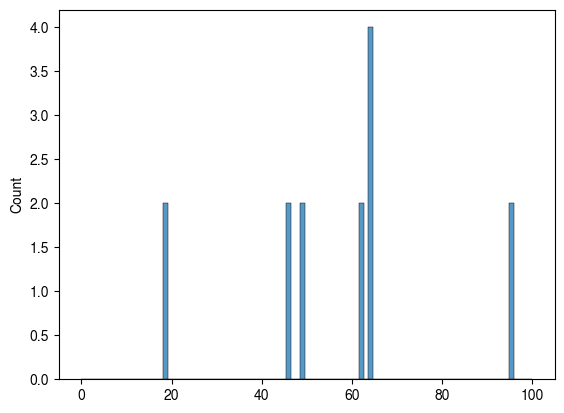

In [34]:
children_radius = np.sqrt(children_vtx.daughter_vx**2 + children_vtx.daughter_vy**2 + children_vtx.daughter_vz**2)

sns.histplot(children_radius, bins=np.linspace(0, 100, 100))

In [ ]:
tracker_hits

,event_id,subentry,cellID,time,x,y,z,detector,particle_id,r,R,phi,theta,eta
0,0,0,60077547270377222,0.144050,30.402032,-9.939022,2.208908,PixelBarrelReadout,335,31.985429,32.061612,-0.315967,1.501846,0.069005
1,0,1,6649970879241750,0.292478,63.335321,-24.882639,-17.336838,PixelBarrelReadout,335,68.047840,70.221610,-0.374346,1.820263,-0.252096
2,0,2,70070007727796262,0.481834,102.399987,-49.665924,-41.886809,PixelBarrelReadout,335,113.808881,121.272281,-0.451591,1.923456,-0.360205
3,0,3,59497099620140854,0.716374,145.373103,-87.735785,-71.972332,PixelBarrelReadout,335,169.796664,184.420507,-0.543005,1.971713,-0.412109
4,0,4,6122261132484118,0.302634,63.569908,-24.275881,-18.914919,PixelBarrelReadout,1783,68.047422,70.627373,-0.364786,1.841919,-0.274506
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6375,0,654,15663745823054,9.288465,-1020.603412,66.962789,2604.500000,LongStripEndcapReadout,1759,1022.797800,2798.130731,3.076076,0.374201,1.664344
6376,0,655,15685221708110,9.306403,-1022.580861,66.846928,2609.500000,LongStripEndcapReadout,1759,1024.763450,2803.503233,3.076315,0.374202,1.664342
6377,0,656,15706696548686,9.345511,-1026.930085,66.588938,2620.500000,LongStripEndcapReadout,1759,1029.086724,2815.322315,3.076841,0.374203,1.664339
6378,0,657,15668040794446,9.363808,-1028.907160,66.468849,2625.500000,LongStripEndcapReadout,1759,1031.051915,2820.694649,3.077081,0.374203,1.664338


## Sanity checks (Hidden Valley truth)

These checks focus on the **`4900*`** Hidden-Valley PDGs and ensure the event record matches the intended semi-visible benchmark:

- `4900111` (**pi_v0**) is **stable** (MET)
- other dark hadrons (e.g. `4900113`, `±4900211`, `±4900213`) **decay promptly** to SM quarks
- no unintended stable *charged* dark hadrons remain in the final state (these can cause Geant4/DD4hep issues and are also a different signature)

In [10]:
import numpy as np
import pandas as pd


def _event_slice(df: pd.DataFrame, event_id: int) -> pd.DataFrame:
    """Filter a dataframe to a single `event_id`.

    Inputs:
        df: DataFrame with an `event_id` column.
        event_id: Event id to select.

    Outputs:
        A filtered copy of `df` containing only rows with `event_id`.
    """
    return df[df["event_id"] == event_id].copy()


def _daughter_ids_for_parent(
    particles_df_event: pd.DataFrame,
    daughters_df_event: pd.DataFrame,
    parent_row,
) -> list[int]:
    """Get the daughter `particle_id` list for a single parent row.

    Notes:
        - `daughters_begin/end` are **per-event offsets** into the per-event daughters link table.

    Inputs:
        particles_df_event: Particles filtered to a single event (must include `particle_id`).
        daughters_df_event: Daughters link table filtered to the same event.
        parent_row: A row-like object with `daughters_begin` and `daughters_end`.

    Outputs:
        List of daughter particle ids (ints). Empty list if range is unset/empty.
    """
    b = int(getattr(parent_row, "daughters_begin"))
    e = int(getattr(parent_row, "daughters_end"))
    if e <= b:
        return []

    d_ev = daughters_df_event.reset_index(drop=True)
    return d_ev.iloc[b:e]["particle_id"].astype(int).to_list()


def summarize_hidden_valley_pdgs(particles_df: pd.DataFrame, prefix: str = "4900") -> pd.DataFrame:
    """Summarize HV-like PDGs (by prefix) per event.

    Inputs:
        particles_df: Full particles dataframe.
        prefix: String prefix to identify HV-like PDGs.

    Outputs:
        DataFrame with one row per event:
          - n_hv_particles: number of particles with PDG starting with `prefix`
          - hv_pdgs: sorted list of unique HV-like PDGs present in the event
    """
    event_ids = sorted(particles_df["event_id"].unique().astype(int).tolist())
    rows: list[dict] = []

    for eid in event_ids:
        p_ev = _event_slice(particles_df, eid)
        pdg_str = p_ev["PDG"].astype(int).astype(str)
        hv = p_ev[pdg_str.str.startswith(prefix)].copy()
        rows.append(
            {
                "event_id": eid,
                "n_hv_particles": int(len(hv)),
                "hv_pdgs": sorted(hv["PDG"].astype(int).unique().tolist()),
            }
        )

    return pd.DataFrame(rows).sort_values("event_id").reset_index(drop=True)


def decay_products_pdgs(
    particles_df_event: pd.DataFrame,
    daughters_df_event: pd.DataFrame,
    parent_row,
) -> list[int]:
    """Return daughter PDGs for a given parent row (event-local)."""
    dau_ids = _daughter_ids_for_parent(particles_df_event, daughters_df_event, parent_row)
    if not dau_ids:
        return []
    return (
        particles_df_event[particles_df_event["particle_id"].isin(dau_ids)]["PDG"].astype(int).to_list()
    )


def is_stable_by_links(p_row) -> bool:
    """Heuristic stability check: stable if daughters range is empty."""
    return int(getattr(p_row, "daughters_end")) <= int(getattr(p_row, "daughters_begin"))


In [11]:
# Hidden Valley PDG summary
hv_summary = summarize_hidden_valley_pdgs(particles)
display(hv_summary)

pdg_str = particles["PDG"].astype(int).astype(str)
hv_particles = particles[pdg_str.str.startswith("4900")].copy()

print("\nUnique HV-like PDGs in this file")
print(np.sort(hv_particles["PDG"].astype(int).unique()))

print("\nMost common HV-like PDGs")
display(hv_particles["PDG"].value_counts().head(20))

# Stability checks (event-local, via daughters_begin/end)
stable_mask = hv_particles["daughters_end"].astype(int) <= hv_particles["daughters_begin"].astype(int)

stable_hv = hv_particles[stable_mask]
print("\nStable HV-like PDGs present:")
print(stable_hv["PDG"].value_counts().sort_index())

# We expect (by construction) stable neutral pi_v0 = 4900111
print("\nStable pi_v0 count (4900111):", int((stable_hv["PDG"] == 4900111).sum()))

# We do NOT want stable charged dark hadrons (these are a different signature and can upset DD4hep)
charged_ids = {4900211, -4900211, 4900213, -4900213}
print("Stable charged dark hadrons present:", stable_hv[stable_hv["PDG"].isin(charged_ids)].shape[0])

,event_id,n_hv_particles,hv_pdgs
0,0,32,"[4900001, 4900021, 4900101, 4900113, 4900211, ..."
1,1,19,"[4900001, 4900021, 4900101, 4900111, 4900211]"
2,2,25,"[4900001, 4900021, 4900101, 4900113, 4900211, ..."
3,3,34,"[4900001, 4900021, 4900101, 4900113, 4900211, ..."
4,4,25,"[4900001, 4900021, 4900101, 4900111, 4900113, ..."
5,5,25,"[4900001, 4900021, 4900101, 4900111, 4900113, ..."
6,6,54,"[4900001, 4900021, 4900101, 4900111, 4900113, ..."
7,7,100,"[4900001, 4900021, 4900101, 4900111, 4900113, ..."



Unique HV-like PDGs in this file
[4900001 4900021 4900101 4900111 4900113 4900211 4900213]

Most common HV-like PDGs


PDG
4900021    136
4900001     82
4900101     31
4900213     20
4900113     17
4900111     15
4900211     13
Name: count, dtype: int64


Stable HV-like PDGs present:
PDG
4900111    15
Name: count, dtype: int64

Stable pi_v0 count (4900111): 15
Stable charged dark hadrons present: 0


,event_id,rho_particle_id,rho_is_stable,rho_daughter_pdgs,rho_decay_ok
0,0,458,False,"[111, 221]",False
1,2,615,False,"[-213, 211]",False
2,3,609,False,"[-211, 211]",False
3,3,613,False,"[-211, 211]",False
4,3,614,False,"[-311, 311]",False
5,4,1920,False,"[-311, 311]",False
6,5,1368,False,"[-311, 311]",False
7,5,1371,False,"[-311, 313]",False
8,6,1053,False,"[-211, 211]",False
9,6,1061,False,"[-211, 213]",False


rho_v0 decay OK fraction: 0.0


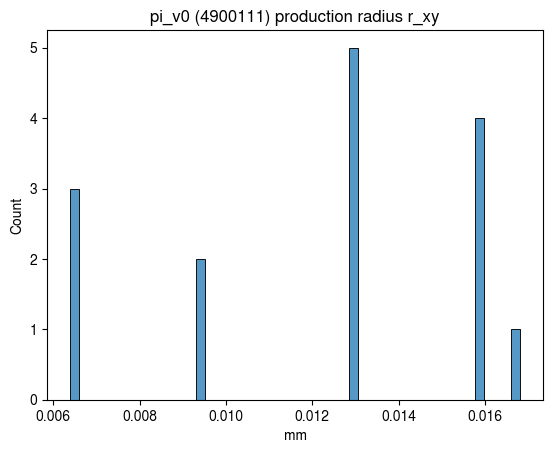

In [12]:
# HV decays: check that rho_v0 (4900113) decays to the configured quark pair (1, -1)
# (and similarly that charged states, if present, decay promptly)
import seaborn as sns
import matplotlib.pyplot as plt

expected_rho_children = {1, -1}

rows = []
for eid in sorted(particles["event_id"].unique().astype(int)):
    p_ev = _event_slice(particles, eid).reset_index(drop=True)
    d_ev = _event_slice(daughters, eid)

    rho = p_ev[p_ev["PDG"] == 4900113]
    for r in rho.itertuples(index=False):
        d_pdgs = decay_products_pdgs(p_ev, d_ev, r)
        rows.append(
            {
                "event_id": eid,
                "rho_particle_id": int(r.particle_id),
                "rho_is_stable": is_stable_by_links(r),
                "rho_daughter_pdgs": sorted([int(x) for x in d_pdgs]),
                "rho_decay_ok": set(d_pdgs) == expected_rho_children,
            }
        )

rho_checks = pd.DataFrame(rows)
display(rho_checks)

if len(rho_checks):
    print("rho_v0 decay OK fraction:", rho_checks["rho_decay_ok"].mean())

# Production radius for stable pi_v0 (4900111) gives a quick check it's near the beamspot
pi0 = hv_particles[hv_particles["PDG"] == 4900111].copy()
if len(pi0):
    pi0["r_prod"] = np.sqrt(pi0["vx"]**2 + pi0["vy"]**2)
    sns.histplot(pi0["r_prod"], bins=50)
    plt.title("pi_v0 (4900111) production radius r_xy")
    plt.xlabel("mm")
    plt.show()

PDG=4900111 mass summary (GeV)
count    15.0
mean     10.0
std       0.0
min      10.0
25%      10.0
50%      10.0
75%      10.0
max      10.0
Name: mass, dtype: float64


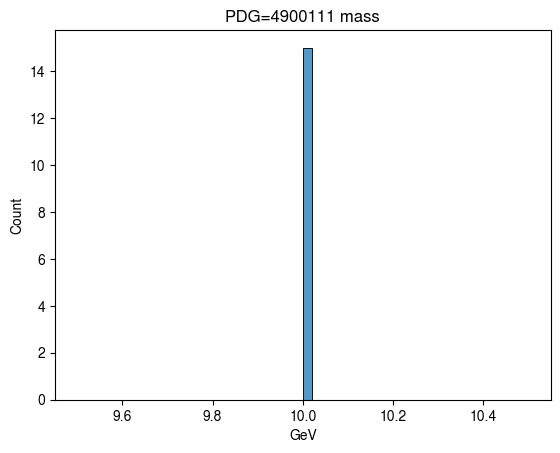

PDG=4900113 mass summary (GeV)
count    17.0
mean     20.0
std       0.0
min      20.0
25%      20.0
50%      20.0
75%      20.0
max      20.0
Name: mass, dtype: float64


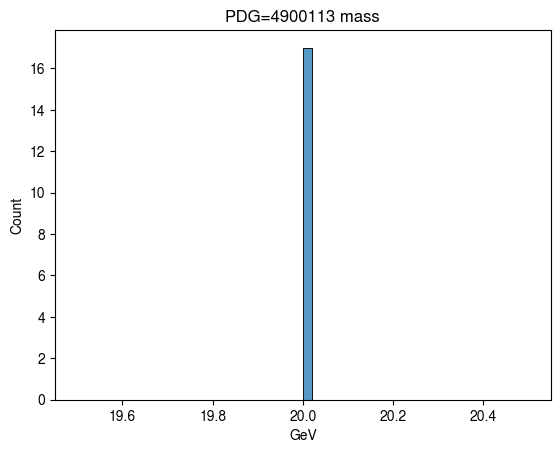

PDG=4900211 mass summary (GeV)
count    13.0
mean     10.0
std       0.0
min      10.0
25%      10.0
50%      10.0
75%      10.0
max      10.0
Name: mass, dtype: float64


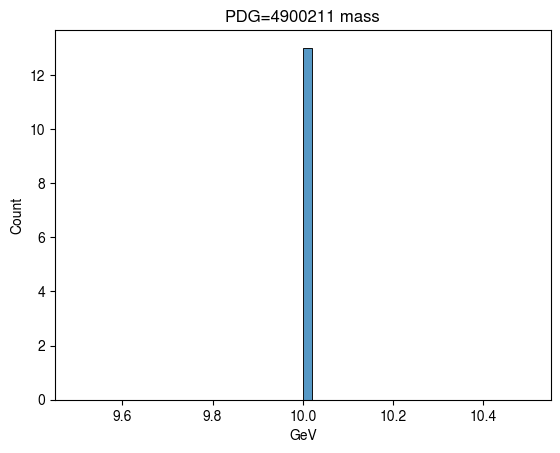

PDG=-4900211 mass summary (GeV)
count     9.0
mean     10.0
std       0.0
min      10.0
25%      10.0
50%      10.0
75%      10.0
max      10.0
Name: mass, dtype: float64


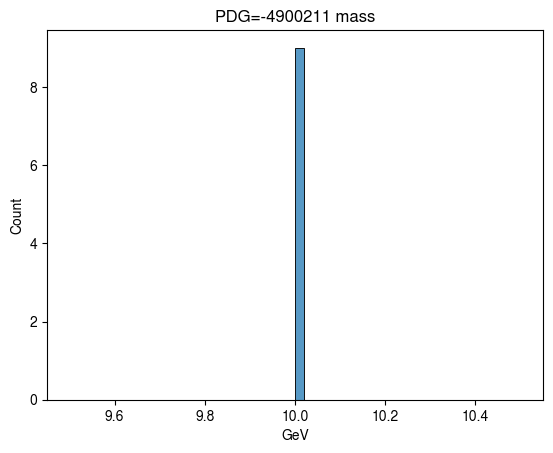

PDG=4900213 mass summary (GeV)
count    20.0
mean     20.0
std       0.0
min      20.0
25%      20.0
50%      20.0
75%      20.0
max      20.0
Name: mass, dtype: float64


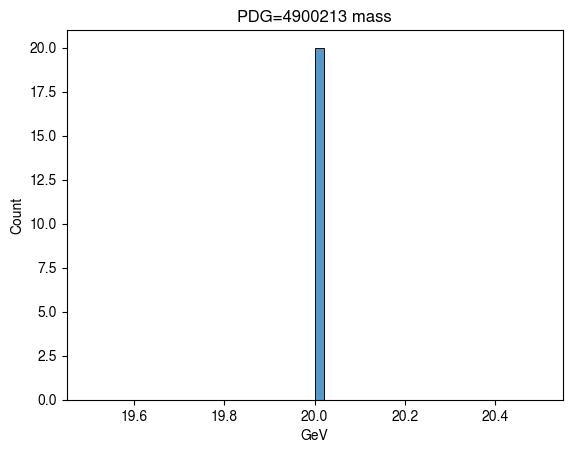

PDG=-4900213 mass summary (GeV)
count    24.0
mean     20.0
std       0.0
min      20.0
25%      20.0
50%      20.0
75%      20.0
max      20.0
Name: mass, dtype: float64


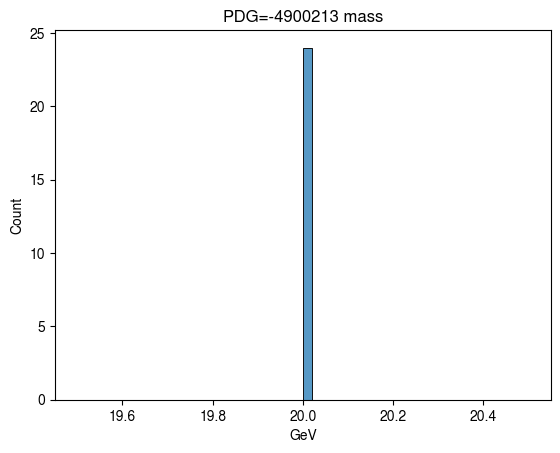

HV-like PDGs present (4900*): [4900001 4900021 4900101 4900111 4900113 4900211 4900213]

Most common PDGs


PDG
 11            30940
-11            23022
 2212           6191
-211            5001
 211            4847
 21             4449
 22             4158
 111            1254
 2112            982
 321             335
 2               255
 1000010020      250
-13              217
-321             203
 1               202
-1               180
 1000140280      156
 113             149
 4900021         136
 223             133
 221             127
 13              117
 213             113
-2               107
-213             107
 130             106
 310             105
-2212             99
 311              93
-4900001          86
Name: count, dtype: int64


Most common HV-like PDGs


PDG
4900021    136
4900001     82
4900101     31
4900213     20
4900113     17
4900111     15
4900211     13
Name: count, dtype: int64

In [13]:
# Quick mass + PDG sanity checks (Hidden Valley)

def _mass_series(particles_df: pd.DataFrame, pdg: int) -> pd.Series:
    """Extract mass values for a given PDG.

    Inputs:
        particles_df: Full particles dataframe.
        pdg: PDG id to filter.

    Outputs:
        Pandas Series of masses (float).
    """
    return particles_df.loc[particles_df["PDG"] == pdg, "mass"].astype(float)


for pdg in (4900111, 4900113, 4900211, -4900211, 4900213, -4900213):
    m = _mass_series(particles, pdg)
    if len(m) == 0:
        continue
    print(f"PDG={pdg} mass summary (GeV)")
    print(m.describe())
    sns.histplot(m, bins=50)
    plt.title(f"PDG={pdg} mass")
    plt.xlabel("GeV")
    plt.show()

pdg_str = particles["PDG"].astype(int).astype(str)
hv_like = particles[pdg_str.str.startswith("4900")]["PDG"].astype(int).unique()
print("HV-like PDGs present (4900*):", np.sort(hv_like) if len(hv_like) else "None")

print("\nMost common PDGs")
display(particles["PDG"].value_counts().head(30))

print("\nMost common HV-like PDGs")
display(particles[pdg_str.str.startswith("4900")]["PDG"].value_counts().head(30))